# Прогнозируем волатильность Bitcoin

### Подключаем библиотеки

In [ ]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.naive import NaiveForecaster
from sktime.utils import plot_series
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from feature_engineering import build_hourly_features
from feature_selection import forward_selection
from neural_models import GRUModel, LSTMModel, RNNModel
from torch_training import (
    create_sequences,
    epochs,
    patience,
    predict_model,
    pytorch_model_fit,
    pytorch_model_validation,
)


## Загружаем данные

### Читаем файл

In [4]:
panel_hourly = pd.read_csv(
    "BTCUSDT_1h_2020_2025.csv",
    parse_dates=["timestamp"],
)

panel_hourly = panel_hourly.sort_values("timestamp").copy()
panel_hourly["open_time"] = pd.to_datetime(
    panel_hourly["timestamp"],
    utc=True,
)

### Проверяем шаг

In [6]:
expected_step = pd.Timedelta(1, unit="h")
time_step = panel_hourly["open_time"].diff()
gap_mask = time_step.gt(expected_step)

gaps = pd.DataFrame(
    {
        "previous_time": panel_hourly["open_time"].shift(1)[gap_mask],
        "next_time": panel_hourly.loc[gap_mask, "open_time"],
        "missing_hours": (
                time_step[gap_mask] / expected_step - 1
        ).astype(int),
    }
).reset_index(drop=True)

print(f"Разрывов: {len(gaps)}")
print(f"Всего пропущено часов: {gaps['missing_hours'].sum()}")
gaps

Разрывов: 15
Всего пропущено часов: 31


,previous_time,next_time,missing_hours
0,2020-02-09 01:00:00+00:00,2020-02-09 03:00:00+00:00,1
1,2020-02-19 11:00:00+00:00,2020-02-19 17:00:00+00:00,5
2,2020-03-04 09:00:00+00:00,2020-03-04 11:00:00+00:00,1
3,2020-04-25 01:00:00+00:00,2020-04-25 04:00:00+00:00,2
4,2020-06-28 01:00:00+00:00,2020-06-28 05:00:00+00:00,3
5,2020-11-30 05:00:00+00:00,2020-11-30 07:00:00+00:00,1
6,2020-12-21 14:00:00+00:00,2020-12-21 18:00:00+00:00,3
7,2020-12-25 01:00:00+00:00,2020-12-25 03:00:00+00:00,1
8,2021-02-11 03:00:00+00:00,2021-02-11 05:00:00+00:00,1
9,2021-03-06 01:00:00+00:00,2021-03-06 03:00:00+00:00,1


### Настраиваем индекс

In [8]:
df = (
    panel_hourly
    .set_index("open_time")
    .drop(columns="timestamp")
    .asfreq("h")
)

### Помечаем пропуски

In [10]:
df['is_gap'] = df['close'].isna().astype(int)
missing = df['close'].isna()
previous_close = df['close'].ffill()
for col in ["open", "high", "low", "close"]:
    df.loc[missing, col] = previous_close[missing]
volume_cols = [
    "volume",
    "quote_volume",
    "trades",
    "taker_buy_volume",
    "taker_buy_quote_volume",
]
df.loc[missing, volume_cols] = 0

## Готовим цель

### Считаем лог-доходности

In [12]:
df["log_return"] = np.log(df["close"]).diff()

future_squared_returns = (
    df["log_return"]
    .pow(2)
    .rolling(window=24, min_periods=24)
    .sum()
    .shift(-24)
)

df["target_rv_24h"] = np.sqrt(future_squared_returns)
df["close_time"] = df.index + pd.Timedelta(1, unit="h")

### Строим цель

In [14]:
df["future_gap_24h"] = sum(
    df['is_gap'].shift(-i) for i in range(1, 25))
df.loc[df["future_gap_24h"] > 0, "target_rv_24h"] = np.nan
df_for_decomp = df['target_rv_24h']

### Агрегируем день

In [16]:
df.reset_index()

,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_volume,taker_buy_quote_volume,ignore,is_gap,log_return,target_rv_24h,future_gap_24h
0,2020-01-01 00:00:00+00:00,7195.24,7196.25,7175.46,7177.02,511.814901,2020-01-01 01:00:00+00:00,3.675857e+06,7640.0,226.153126,1.624289e+06,0.0,0,NaN,0.010817,0.0
1,2020-01-01 01:00:00+00:00,7176.47,7230.00,7175.71,7216.27,883.052603,2020-01-01 02:00:00+00:00,6.365953e+06,9033.0,570.721419,4.114804e+06,0.0,0,0.005454,0.009747,0.0
2,2020-01-01 02:00:00+00:00,7215.52,7244.87,7211.41,7242.85,655.156809,2020-01-01 03:00:00+00:00,4.736719e+06,7466.0,357.180263,2.582514e+06,0.0,0,0.003677,0.009532,0.0
3,2020-01-01 03:00:00+00:00,7242.66,7245.00,7220.00,7225.01,783.724867,2020-01-01 04:00:00+00:00,5.667367e+06,8337.0,394.810811,2.854987e+06,0.0,0,-0.002466,0.010731,0.0
4,2020-01-01 04:00:00+00:00,7225.00,7230.00,7215.03,7217.27,467.812578,2020-01-01 05:00:00+00:00,3.379094e+06,5896.0,243.514706,1.759053e+06,0.0,0,-0.001072,0.010823,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,2025-12-31 19:00:00+00:00,87684.08,87870.02,87516.70,87541.85,622.188590,2025-12-31 20:00:00+00:00,5.456200e+07,128037.0,299.319450,2.625010e+07,0.0,0,-0.001623,NaN,NaN
52604,2025-12-31 20:00:00+00:00,87541.85,87712.13,87250.00,87662.01,770.327430,2025-12-31 21:00:00+00:00,6.737396e+07,171298.0,356.394200,3.117588e+07,0.0,0,0.001372,NaN,NaN
52605,2025-12-31 21:00:00+00:00,87662.01,87879.04,87662.01,87799.97,383.855500,2025-12-31 22:00:00+00:00,3.369446e+07,65264.0,197.123230,1.730224e+07,0.0,0,0.001573,NaN,NaN
52606,2025-12-31 22:00:00+00:00,87799.97,87879.04,87656.19,87728.29,236.186970,2025-12-31 23:00:00+00:00,2.073407e+07,55353.0,135.863960,1.192726e+07,0.0,0,-0.000817,NaN,NaN


### Выбираем колонки

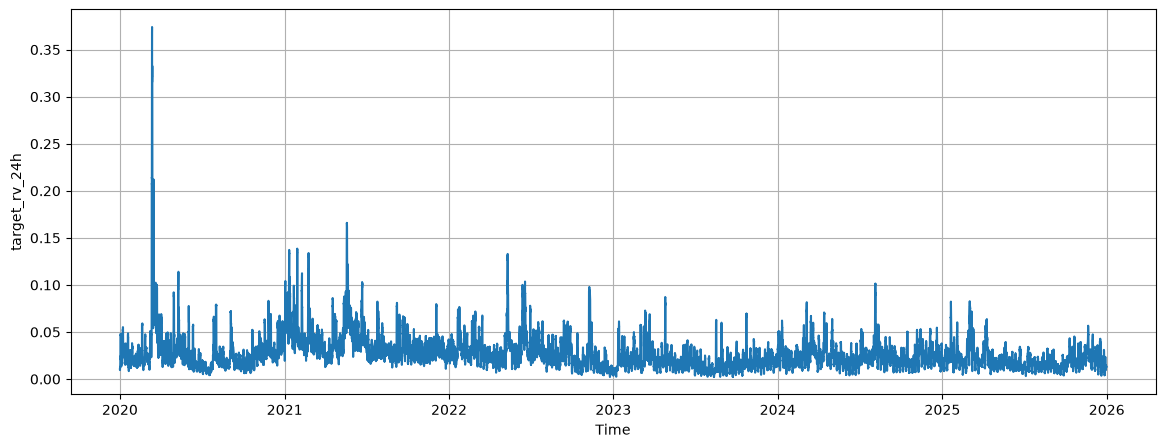

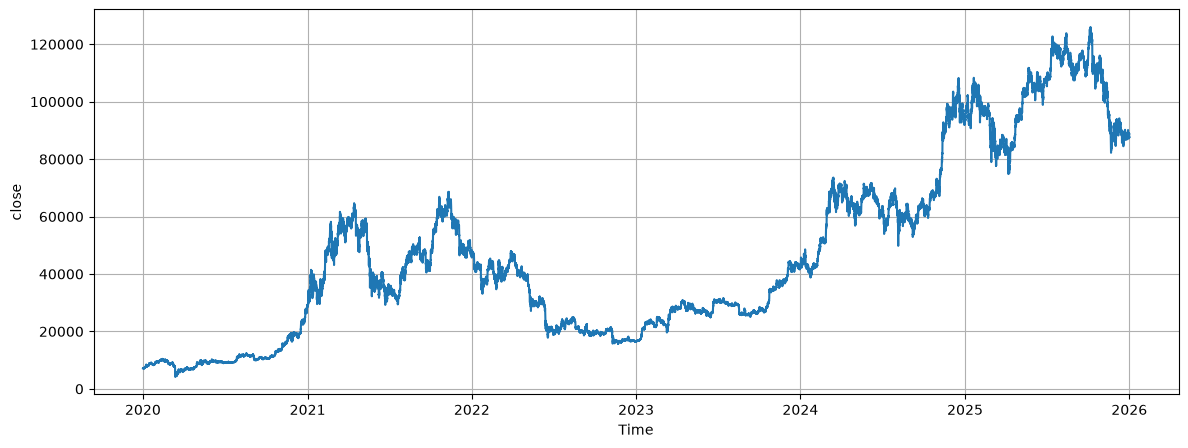

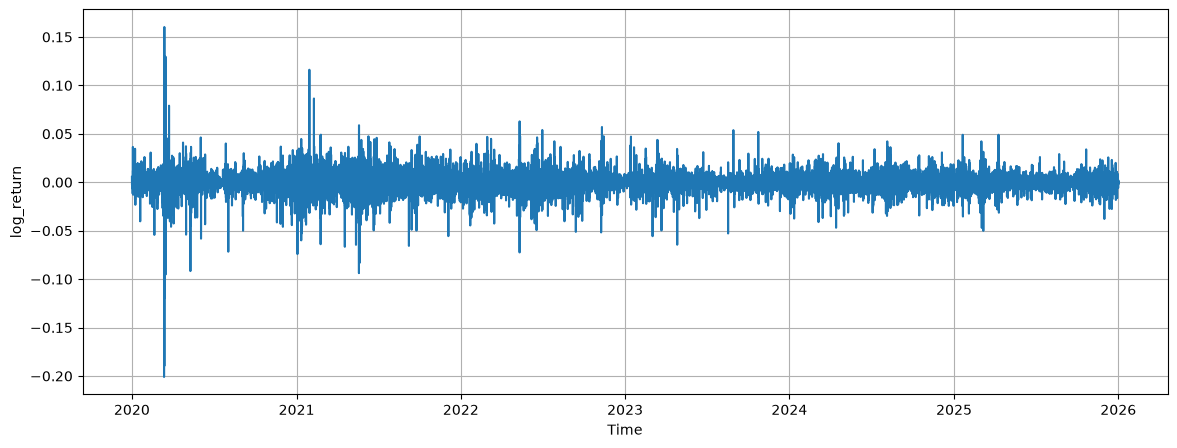

In [18]:
columns = ['target_rv_24h', 'close', 'log_return']
for col in columns:
    plt.figure(figsize=(14, 5))
    plt.plot(df['close_time'], df[col])
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()


### Собираем графики

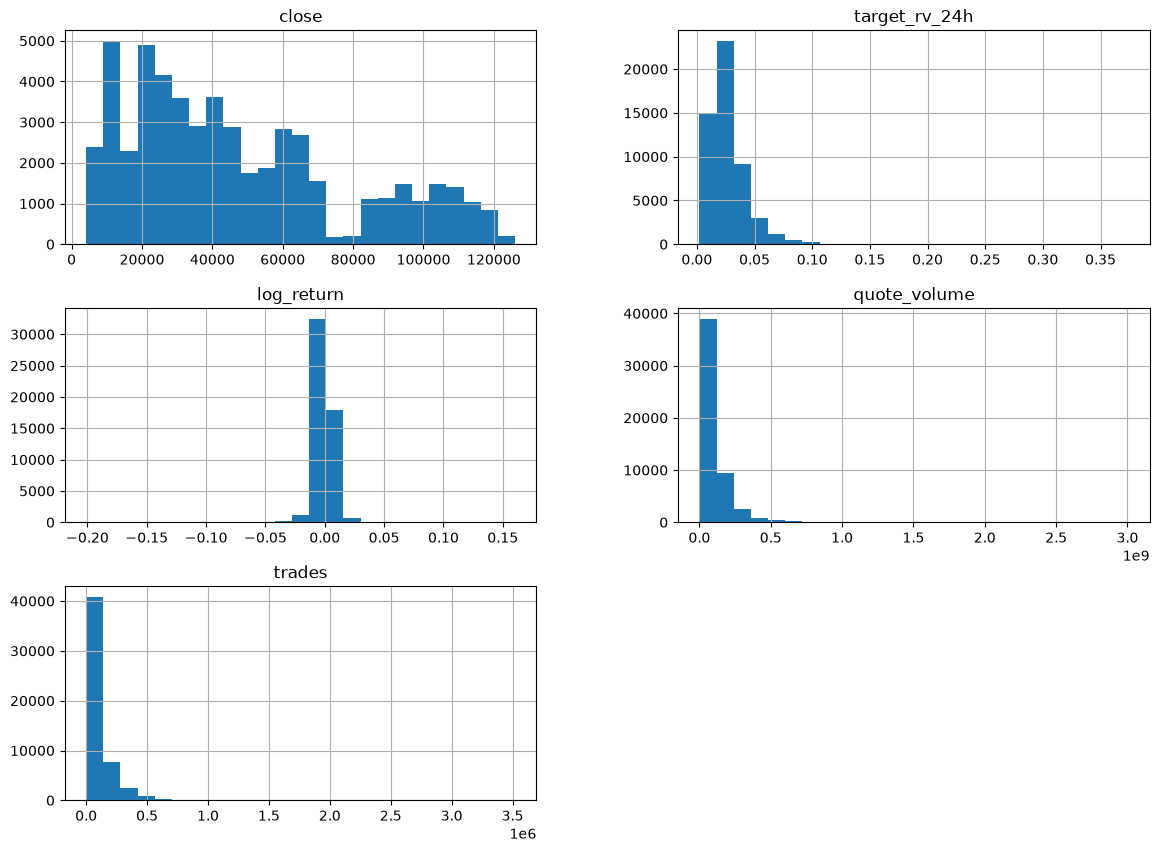

In [20]:
histog = ['close', 'target_rv_24h', 'log_return', 'quote_volume', 'trades']
df[histog].hist(bins=25, figsize=(14, 10))
plt.show()

### Рисуем гистограммы

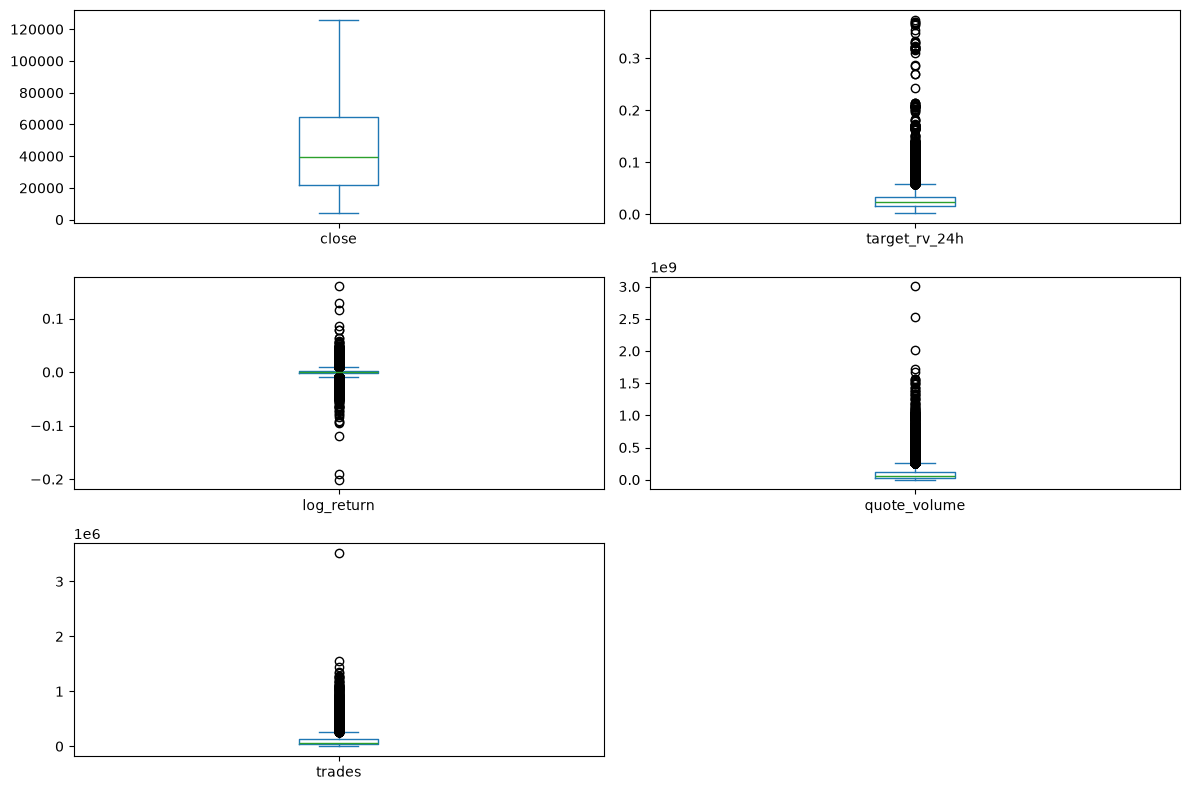

In [22]:
df[histog].plot(
    kind="box",
    subplots=True,
    layout=(3, 2),
    figsize=(12, 8),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.grid(True)
plt.show()

### Готовим ряд

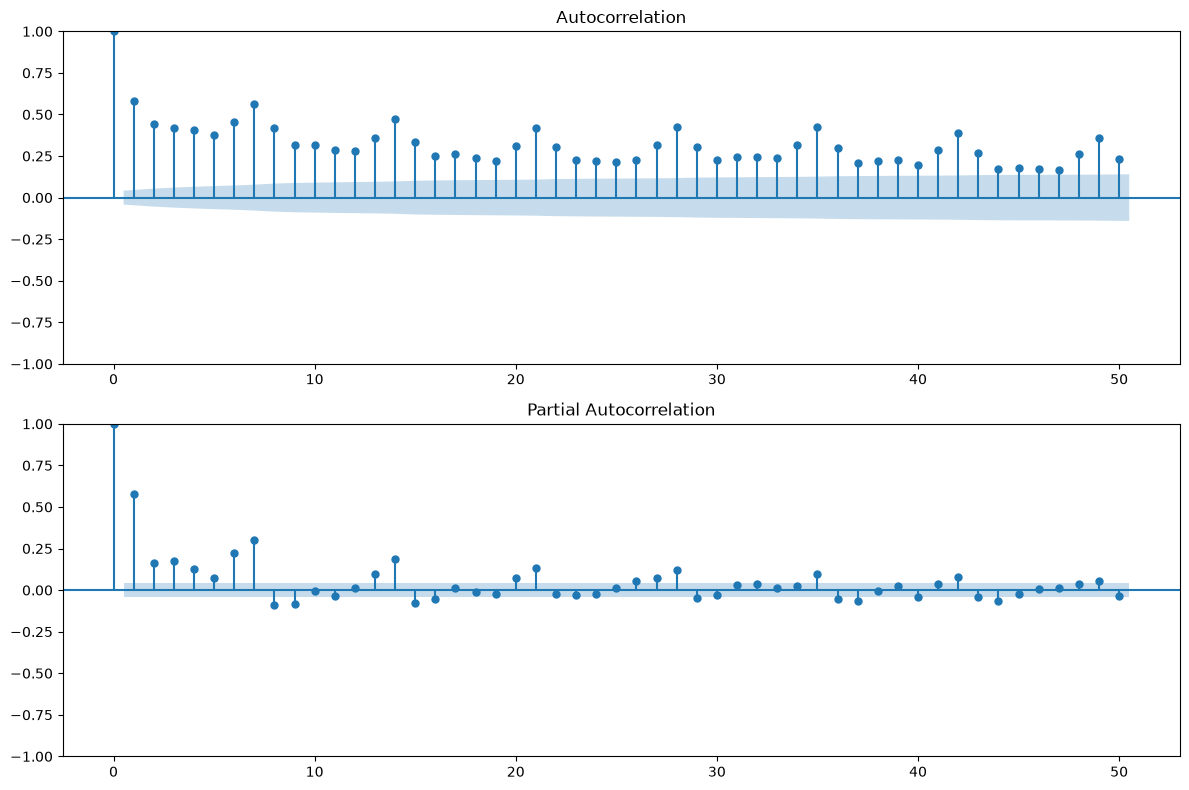

In [66]:
series = df.loc[
    df["close_time"].dt.hour.eq(0),
    "target_rv_24h"
].dropna()
series_orig = series
series = np.log(series)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(series, lags=50, ax=axes[0])
plot_pacf(series, lags=50, ax=axes[1], method="ywm")
plt.tight_layout()
plt.show()

## Строим признаки

### Вычисляем признаки

In [32]:
hourly_features, feature_groups = build_hourly_features(df)
feature_columns = hourly_features.columns.tolist()

### Собираем датасет

In [34]:
model_hourly = pd.concat(
    [
        df[["close_time", "target_rv_24h", "future_gap_24h"]],
        hourly_features,
    ],
    axis=1,
)

daily_model_df = (
    model_hourly.loc[model_hourly["close_time"].dt.hour.eq(0)]
    .set_index("close_time")
    .sort_index()
)

daily_model_df = daily_model_df.loc[
    daily_model_df["target_rv_24h"].notna()
].copy()

constant_features = [
    column
    for column in feature_columns
    if daily_model_df[column].nunique(dropna=True) <= 1
]
non_constant_features = [
    column for column in feature_columns if column not in constant_features
]
duplicate_mask = daily_model_df[non_constant_features].T.duplicated()
duplicate_features = duplicate_mask.index[duplicate_mask].tolist()
model_feature_columns = [
    column
    for column in non_constant_features
    if column not in duplicate_features
]
missing_share = daily_model_df[model_feature_columns].isna().mean()

print(f"Дневных наблюдений: {len(daily_model_df)}")
print(f"Признаков до отбора: {len(feature_columns)}")
print(f"Константных после выбора 00:00: {len(constant_features)}")
print(f"Полных дубликатов признаков: {len(duplicate_features)}")
print(f"Признаков после технической очистки: {len(model_feature_columns)}")
print(f"Максимальная доля NaN: {missing_share.max():.2%}")

pd.DataFrame(
    {
        "feature": model_feature_columns,
        "missing_share": missing_share.values,
    }
).sort_values("missing_share", ascending=False).head(15)

Дневных наблюдений: 2191
Признаков до отбора: 364
Константных после выбора 00:00: 7
Полных дубликатов признаков: 9
Признаков после технической очистки: 348
Максимальная доля NaN: 1.32%


,feature,missing_share
61,seasonal_lag_rv24_672h,0.013236
49,seasonal_lag_volume_672h,0.012780
37,seasonal_lag_return_672h,0.012780
25,seasonal_lag_close_672h,0.012780
60,seasonal_lag_rv24_504h,0.010041
36,seasonal_lag_return_504h,0.009585
24,seasonal_lag_close_504h,0.009585
48,seasonal_lag_volume_504h,0.009585
59,seasonal_lag_rv24_336h,0.006846
302,autocorr_return_w336_lag24,0.006846


## Отбираем признаки

### Убираем пропуски

In [40]:
df_result = daily_model_df.dropna(subset=["target_rv_24h"]).copy()

X = df_result[model_feature_columns]
y = df_result["target_rv_24h"]

split_idx = int(0.8 * len(X))

X_train_full = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train_full = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

### Делим по времени

In [42]:
feature_ts_split = TimeSeriesSplit(
    n_splits=5,
    test_size=180,
    gap=1,
)

selected_indices, selection_scores = forward_selection(
    X_train_full,
    y_train_full,
    feature_ts_split,
)

selected_columns = X.columns[selected_indices].tolist()

print("Выбрано признаков:", len(selected_columns))

Шаг 1: exp_volatility_168h, средний R² = 0.0633
Шаг 2: is_weekend, средний R² = 0.2064
Шаг 3: market_candle_range_ratio, средний R² = 0.2595
Шаг 4: roll_return_q25_72h, средний R² = 0.2856
Шаг 5: day_of_week_cos, средний R² = 0.3020
Шаг 6: bollinger_width_24h, средний R² = 0.3144
Шаг 7: coefficient_variation_volume_12h, средний R² = 0.3248
Шаг 8: roll_return_range_72h, средний R² = 0.3306
Шаг 9: coefficient_variation_close_72h, средний R² = 0.3373
Шаг 10: lag_rv24_6h, средний R² = 0.3440
Шаг 11: macd_6_24_9_signal, средний R² = 0.3499
Шаг 12: rsi_30h, средний R² = 0.3582
Шаг 13: roll_return_median_12h, средний R² = 0.3637
Шаг 14: roll_rv24_std_168h, средний R² = 0.3669
Шаг 15: negative_semivariance_168h, средний R² = 0.3735
Шаг 16: roll_return_var_168h, средний R² = 0.3759
Шаг 17: autocorr_return_w168_lag1, средний R² = 0.3779
Шаг 18: roc_12h, средний R² = 0.3792
Шаг 19: lag_volume_2h, средний R² = 0.3806
Шаг 20: seasonal_lag_return_48h, средний R² = 0.3820
Шаг 21: roll_return_q75_336h

## Обучаем сети

### Задаем длину окна

In [50]:
seq_length = 60

X_all_selected = X_train_full[selected_columns].copy()
y_all = y_train_full.copy()
X_test_selected = X_test[selected_columns].copy()


torch.manual_seed(42)

input_size = X_all_selected.shape[1]

models = {
    "LSTM": LSTMModel(
        input_size=input_size,
        hidden_size=32,
    ),
    "RNN": RNNModel(
        input_size=input_size,
        hidden_size=32,
    ),
    "GRU": GRUModel(
        input_size=input_size,
        hidden_size=32,
    ),
}

ts_split = TimeSeriesSplit(
    n_splits=5,
    test_size=180,
    gap=1,
)

results_valid = {}
results_test = {}

for name, base_model in models.items():
    print(f"\nМодель: {name}")
    results_valid[name] = {"folds": []}

    for fold, (train_index, valid_index) in enumerate(
        ts_split.split(X_all_selected),
        start=1,
    ):
        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()

        X_train_imputed = imputer.fit_transform(
            X_all_selected.iloc[train_index]
        )
        X_train_final = scaler.fit_transform(X_train_imputed)

        valid_context_start = max(
            0,
            valid_index[0] - seq_length + 1,
        )
        valid_context_index = np.arange(
            valid_context_start,
            valid_index[-1] + 1,
        )

        X_valid_context_imputed = imputer.transform(
            X_all_selected.iloc[valid_context_index]
        )
        X_valid_context_final = scaler.transform(
            X_valid_context_imputed
        )

        y_train_fold = y_all.iloc[train_index].to_numpy()
        y_valid_context = y_all.iloc[
            valid_context_index
        ].to_numpy()

        X_rnn_train, y_rnn_train = create_sequences(
            X_train_final,
            y_train_fold,
            seq_length=seq_length,
        )
        X_rnn_valid, y_rnn_valid = create_sequences(
            X_valid_context_final,
            y_valid_context,
            seq_length=seq_length,
        )

        print(
            f"Fold {fold}: ",
            f"train={X_rnn_train.shape}, ",
            f"valid={X_rnn_valid.shape}",
        )

        fold_model = deepcopy(base_model)
        fold_model, train_losses, valid_losses = (
            pytorch_model_validation(
                fold_model,
                X_rnn_train,
                y_rnn_train,
                X_rnn_valid,
                y_rnn_valid,
                epochs=epochs,
                patience=patience,
            )
        )

        results_valid[name]["folds"].append(
            {
                "fold": fold,
                "best_valid_loss": float(np.min(valid_losses)),
                "best_epoch": int(np.argmin(valid_losses) + 1),
                "train_losses": train_losses,
                "valid_losses": valid_losses,
            }
        )

    fold_losses = [
        fold_result["best_valid_loss"]
        for fold_result in results_valid[name]["folds"]
    ]
    results_valid[name]["mean_valid_loss"] = float(
        np.mean(fold_losses)
    )
    results_valid[name]["std_valid_loss"] = float(
        np.std(fold_losses)
    )

    print(
        f"{name}: validation MSE "
        f"{results_valid[name]['mean_valid_loss']:.6f} "
        f"± {results_valid[name]['std_valid_loss']:.6f}"
    )


best_model_name = min(
    results_valid,
    key=lambda model_name: results_valid[model_name]["mean_valid_loss"],
)

best_epochs = [
    fold_result["best_epoch"]
    for fold_result in results_valid[best_model_name]["folds"]
]
final_epochs = max(1, int(np.median(best_epochs)))

print(f"\nЛучшая модель: {best_model_name}")
print(f"Эпох для финального обучения: {final_epochs}")

final_imputer = SimpleImputer(strategy="median")
final_scaler = StandardScaler()

X_dev_imputed = final_imputer.fit_transform(X_all_selected)
X_dev_final = final_scaler.fit_transform(X_dev_imputed)

X_test_imputed = final_imputer.transform(X_test_selected)
X_test_final = final_scaler.transform(X_test_imputed)

X_rnn_final_train, y_rnn_final_train = create_sequences(
    X_dev_final,
    y_all.to_numpy(),
    seq_length=seq_length,
)


X_test_with_context = np.vstack(
    [X_dev_final[-(seq_length - 1):], X_test_final]
)
y_test_with_context = np.concatenate(
    [
        y_all.to_numpy()[-(seq_length - 1):],
        y_test.to_numpy(),
    ]
)

X_rnn_test, y_rnn_test = create_sequences(
    X_test_with_context,
    y_test_with_context,
    seq_length=seq_length,
)

final_model = deepcopy(models[best_model_name])
final_model, final_train_losses = pytorch_model_fit(
    final_model,
    X_rnn_final_train,
    y_rnn_final_train,
    epochs=final_epochs,
)

test_loss, test_predictions, test_targets = predict_model(
    final_model,
    X_rnn_test,
    y_rnn_test,
)

test_mae = mean_absolute_error(test_targets, test_predictions)
test_rmse = np.sqrt(mean_squared_error(test_targets, test_predictions))
test_r2 = r2_score(test_targets, test_predictions)

results_test[best_model_name] = {
    "test_mse": float(test_loss),
    "test_mae": float(test_mae),
    "test_rmse": float(test_rmse),
    "test_r2": float(test_r2),
    "predictions": test_predictions,
    "targets": test_targets,
    "train_losses": final_train_losses,
}

results = {
    "validation": results_valid,
    "test": results_test,
}

print(
    f"{best_model_name} test: "
    f"MAE={test_mae:.6f}, "
    f"RMSE={test_rmse:.6f}, "
    f"R²={test_r2:.4f}"
)


Модель: LSTM
Fold 1:  train=(792, 60, 51),  valid=(180, 60, 51)
Epoch 001 | train=0.009131 | valid=0.003665
Epoch 002 | train=0.006050 | valid=0.003023
Epoch 003 | train=0.004384 | valid=0.001269
Epoch 004 | train=0.002786 | valid=0.001495
Epoch 005 | train=0.002358 | valid=0.001048
Epoch 006 | train=0.001953 | valid=0.001177
Epoch 007 | train=0.001613 | valid=0.000919
Epoch 008 | train=0.001510 | valid=0.000837
Epoch 009 | train=0.001355 | valid=0.000829
Epoch 010 | train=0.001203 | valid=0.000758
Epoch 011 | train=0.001009 | valid=0.000670
Epoch 012 | train=0.001035 | valid=0.000776
Epoch 013 | train=0.001010 | valid=0.000613
Epoch 014 | train=0.000775 | valid=0.000597
Epoch 015 | train=0.000776 | valid=0.000596
Epoch 016 | train=0.000692 | valid=0.000582
Epoch 017 | train=0.000694 | valid=0.000483
Epoch 018 | train=0.000650 | valid=0.000550
Epoch 019 | train=0.000554 | valid=0.000435
Epoch 020 | train=0.000484 | valid=0.000477
Epoch 021 | train=0.000491 | valid=0.000411
Epoch 022 |

### Измеряем метрики

In [54]:
print(f'MAPE лучшей модели {mean_absolute_percentage_error(test_targets, test_predictions):.6f}')

MAPE лучшей модели 0.349603


### Перечисляем модели

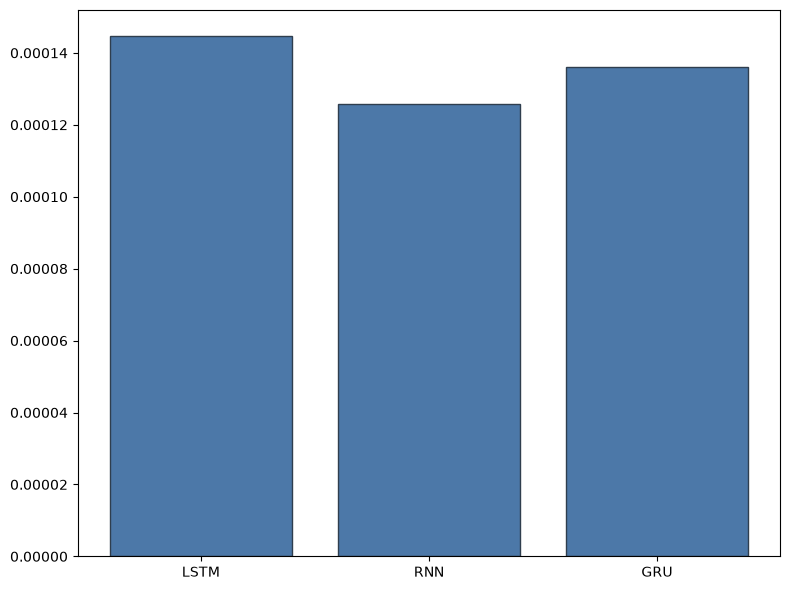

In [56]:
model_names = list(results_valid.keys())
mean_losses = [results_valid[name]['mean_valid_loss'] for name in model_names]
plt.figure(figsize=[8, 6])
plt.bar(model_names, mean_losses,color="#4C78A8",
    edgecolor="#2F3E4E"
)
plt.tight_layout()
plt.show()


### Проверяем фолды

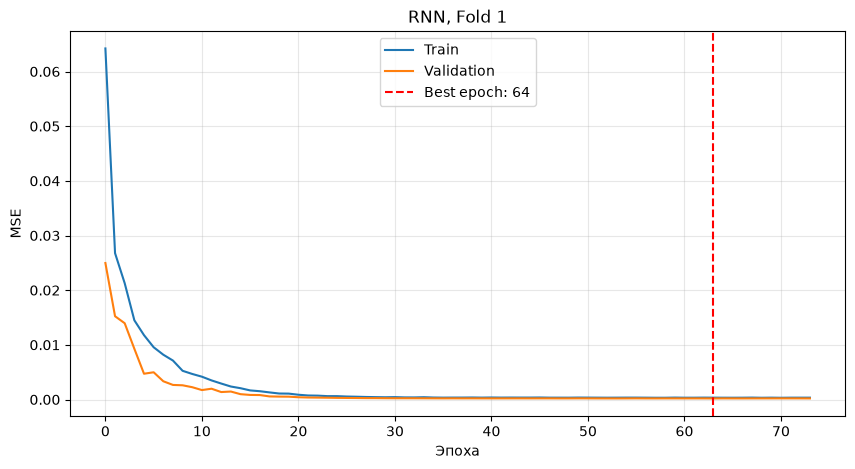

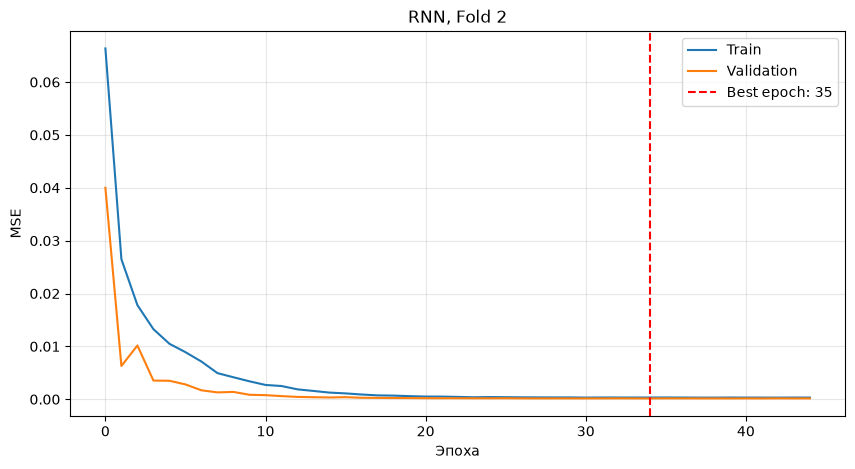

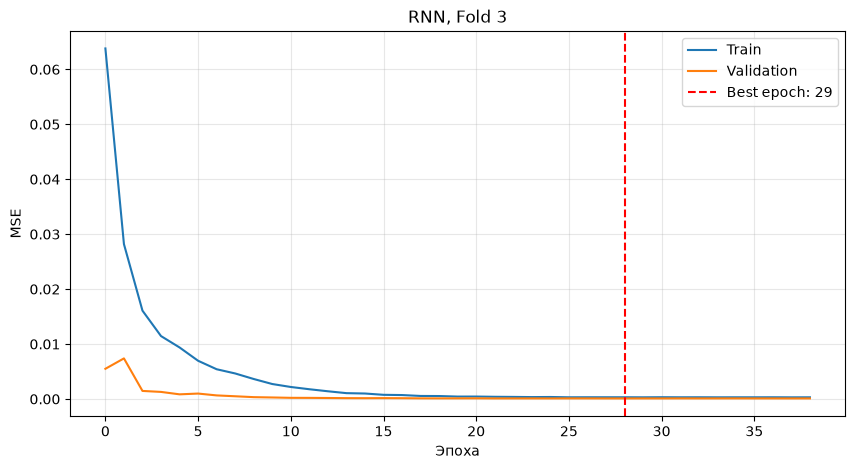

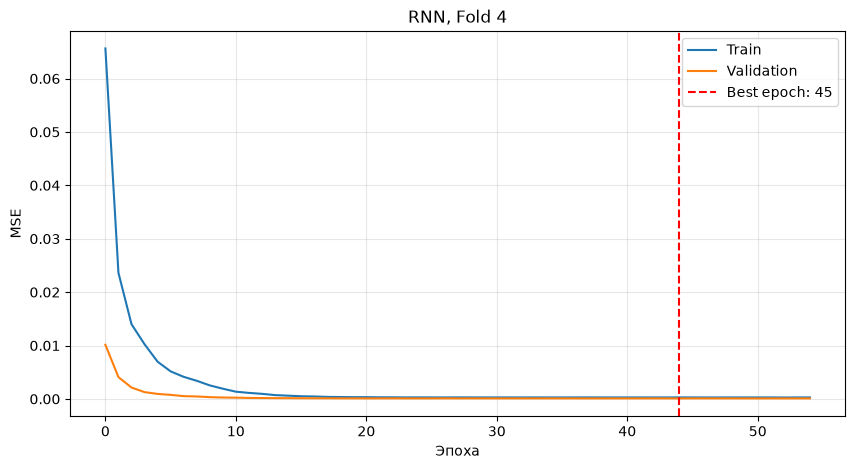

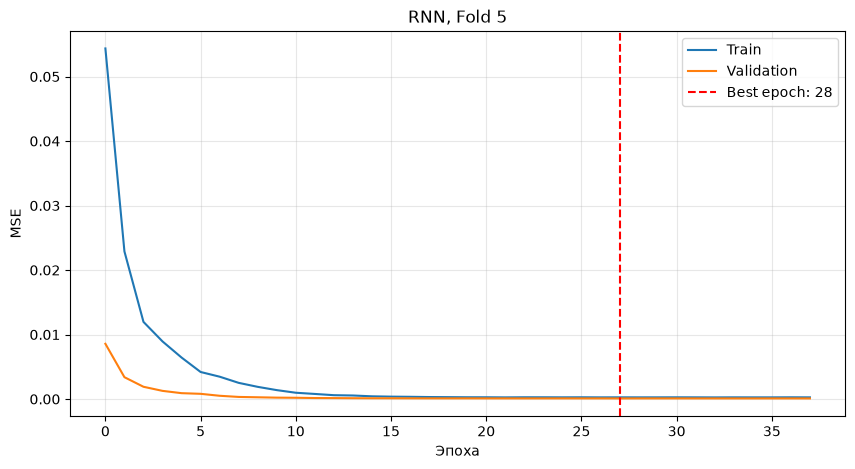

In [58]:
fold_results = results_valid[best_model_name]["folds"]

for fold_result in fold_results:
    train_losses = fold_result["train_losses"]
    valid_losses = fold_result["valid_losses"]
    best_epoch = fold_result["best_epoch"]
    fold = fold_result["fold"]

    plt.figure(figsize=(10, 5))

    plt.plot(
        train_losses,
        label="Train",
    )

    plt.plot(
        valid_losses,
        label="Validation",
    )

    plt.axvline(
        best_epoch - 1,
        color="red",
        linestyle="--",
        label=f"Best epoch: {best_epoch}",
    )

    plt.title(f"{best_model_name}, Fold {fold}")
    plt.xlabel("Эпоха")
    plt.ylabel("MSE")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

### Оцениваем тест

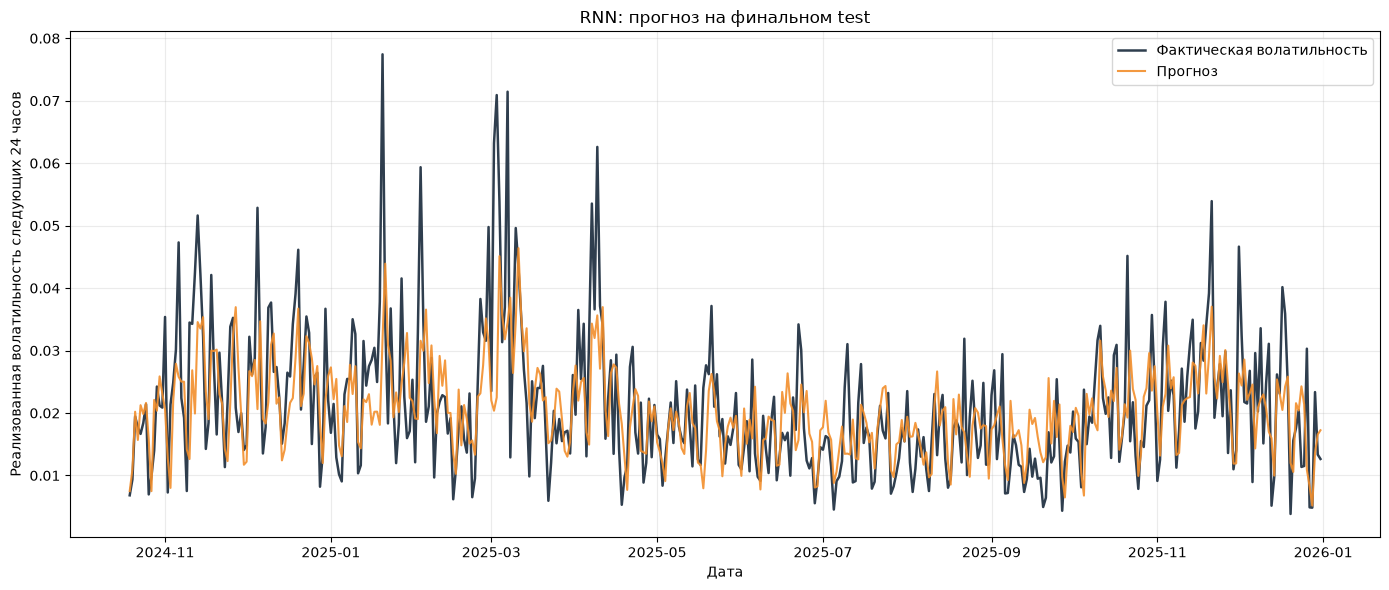

In [60]:
test_result = results_test[best_model_name]

test_predictions = test_result["predictions"]
test_targets = test_result["targets"]

test_dates = y_test.index[-len(test_targets):]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    test_dates,
    test_targets,
    label="Фактическая волатильность",
    color="#2F3E4E",
    linewidth=1.8,
)

ax.plot(
    test_dates,
    test_predictions,
    label="Прогноз",
    color="#F28E2B",
    linewidth=1.5,
    alpha=0.9,
)

ax.set_title(
    f"{best_model_name}: прогноз на финальном test"
)
ax.set_xlabel("Дата")
ax.set_ylabel("Реализованная волатильность следующих 24 часов")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

## Строим baseline

### Готовим ряд

In [113]:
naive_series = y.copy()

date_index = naive_series.index

if date_index.tz is not None:
    date_index = (
        date_index
        .tz_convert("UTC")
        .tz_localize(None)
    )

naive_series.index = date_index.to_period("D")

print(naive_series.index)
print(naive_series.index.freq)

PeriodIndex(['2020-01-02', '2020-01-03', '2020-01-04', '2020-01-05',
             '2020-01-06', '2020-01-07', '2020-01-08', '2020-01-09',
             '2020-01-10', '2020-01-11',
             ...
             '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
             '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
             '2025-12-30', '2025-12-31'],
            dtype='period[D]', name='close_time', length=2191)
<Day>


### Разделяем train

In [114]:
naive_y_train = naive_series.iloc[:split_idx].copy()
naive_y_test = naive_series.iloc[split_idx:].copy()

### Рисуем прогноз

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_series(
    naive_y_train,
    naive_y_test,
    labels=["Train", "Test"],
    ax=ax,
)
ax.set_ylabel("Реализованная волатильность следующих 24 часов")
ax.grid(alpha=0.3)
plt.show()


### Собираем forecasters

In [115]:
forecasters = {
    "Last": NaiveForecaster(
        strategy="last",
    ),
    "Seasonal last": NaiveForecaster(
        strategy="last",
        sp=7,
    ),
    "Mean 48": NaiveForecaster(
        strategy="mean",
        window_length=48,
    ),
}

for forecaster in forecasters.values():
    forecaster.fit(naive_y_train)

predictions = {
    name: []
    for name in forecasters
}

for date, actual_value in naive_y_test.items():
    fh = ForecastingHorizon(
        pd.PeriodIndex([date], freq="D"),
        is_relative=False,
    )

    for name, forecaster in forecasters.items():
        prediction = forecaster.predict(
            fh=fh
        ).iloc[0]

        predictions[name].append(prediction)

        new_observation = pd.Series(
            [actual_value],
            index=pd.PeriodIndex(
                [date],
                freq="D",
            ),
            name=naive_y_train.name,
        )

        forecaster.update(
            new_observation,
            update_params=False,
        )



### Считаем naive

In [116]:
naive_predictions_1 = pd.Series(
    predictions["Last"],
    index=naive_y_test.index,
    name="Last",
)

naive_predictions_2 = pd.Series(
    predictions["Seasonal last"],
    index=naive_y_test.index,
    name="Seasonal last",
)

naive_predictions_3 = pd.Series(
    predictions["Mean 48"],
    index=naive_y_test.index,
    name="Mean 48",
)
neural_predictions = pd.Series(
    test_predictions,
    index=naive_y_test.index,
    name=best_model_name,
)

### Считаем AutoETS

In [ ]:
rolling_ets = AutoETS(
    auto=True,
    sp=7,
    n_jobs=-1,
    information_criterion="bic",
)
rolling_ets.fit(naive_y_train)

autoets_values = []

for date, actual_value in naive_y_test.items():
    current_fh = ForecastingHorizon(
        pd.PeriodIndex([date], freq="D"),
        is_relative=False,
    )

    prediction = rolling_ets.predict(
        fh=current_fh,
    ).iloc[0]
    autoets_values.append(prediction)

    new_observation = pd.Series(
        [actual_value],
        index=pd.PeriodIndex([date], freq="D"),
        name=naive_y_train.name,
    )

    rolling_ets.update(
        new_observation,
        update_params=True,
    )

autoets_predictions = pd.Series(
    autoets_values,
    index=naive_y_test.index,
    name="Rolling AutoETS",
)

## Сопоставляем модели

### Сверяем прогнозы

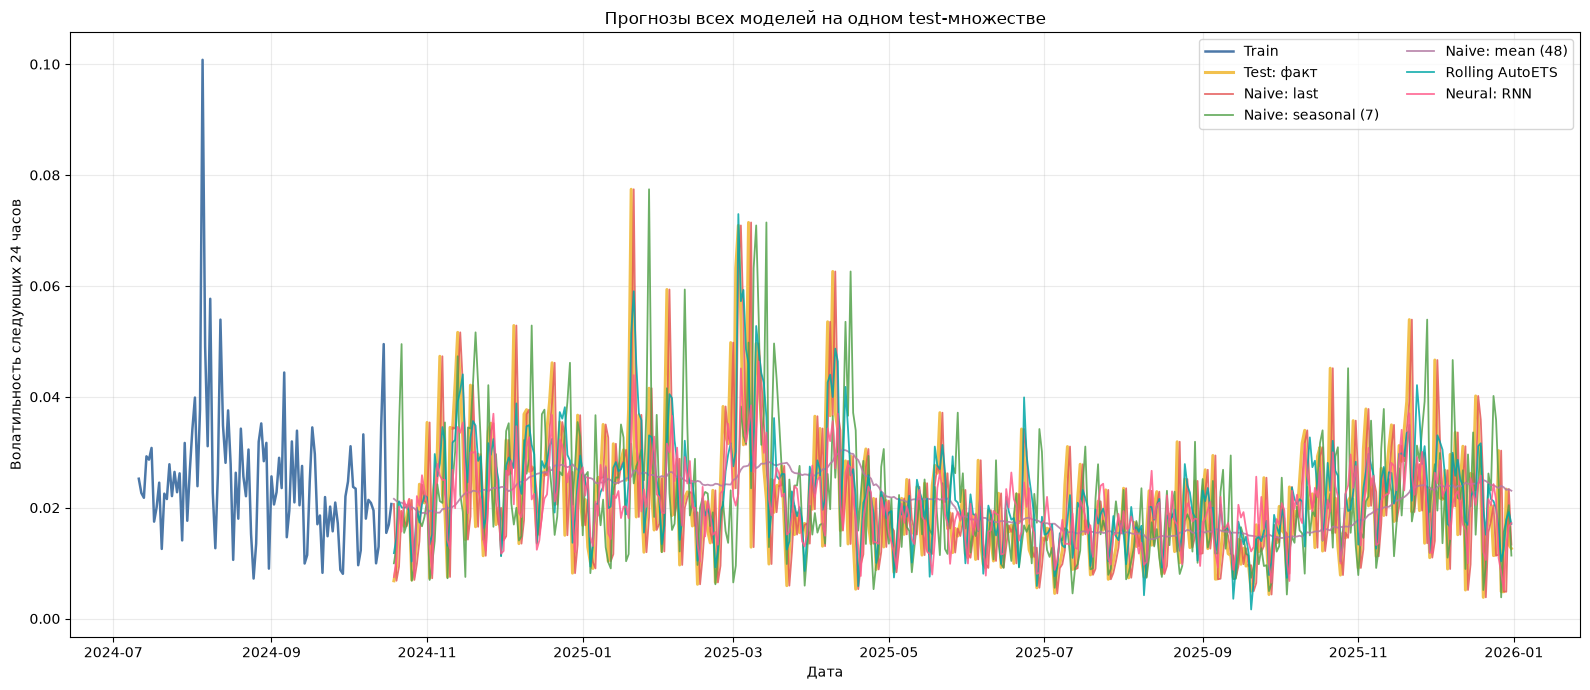

In [118]:
comparison_predictions = {
    "Naive: last": naive_predictions_1,
    "Naive: seasonal (7)": naive_predictions_2,
    "Naive: mean (48)": naive_predictions_3,
    "Rolling AutoETS": autoets_predictions,
    f"Neural: {best_model_name}": neural_predictions,
}

model_colors = {
    "Naive: last": "#E45756",
    "Naive: seasonal (7)": "#54A24B",
    "Naive: mean (48)": "#B279A2",
    "Rolling AutoETS": "#00A6A6",
    f"Neural: {best_model_name}": "#FF5A8A",
}

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(
    naive_y_train.iloc[-100:].index.to_timestamp(),
    naive_y_train.iloc[-100:].values,
    label="Train",
    color="#4C78A8",
    linewidth=1.8,
)
ax.plot(
    naive_y_test.index.to_timestamp(),
    naive_y_test.values,
    label="Test: факт",
    color="#F2C14E",
    linewidth=2.2,
)

for model_name, model_predictions in comparison_predictions.items():
    ax.plot(
        model_predictions.index.to_timestamp(),
        model_predictions.values,
        label=model_name,
        color=model_colors[model_name],
        linewidth=1.3,
        alpha=0.85,
    )

ax.set_title("Прогнозы всех моделей на одном test-множестве")
ax.set_xlabel("Дата")
ax.set_ylabel("Волатильность следующих 24 часов")
ax.grid(alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

### Сводим метрики

,MAE,RMSE,"MAPE, %",R²
Naive: last,0.0088,0.0117,51.7318,-0.0946
Naive: seasonal (7),0.0087,0.0121,43.5926,-0.1655
Naive: mean (48),0.0079,0.0106,49.7549,0.1026
Rolling AutoETS,0.0063,0.0084,35.2215,0.4376
Neural: RNN,0.0065,0.0091,34.9603,0.3478


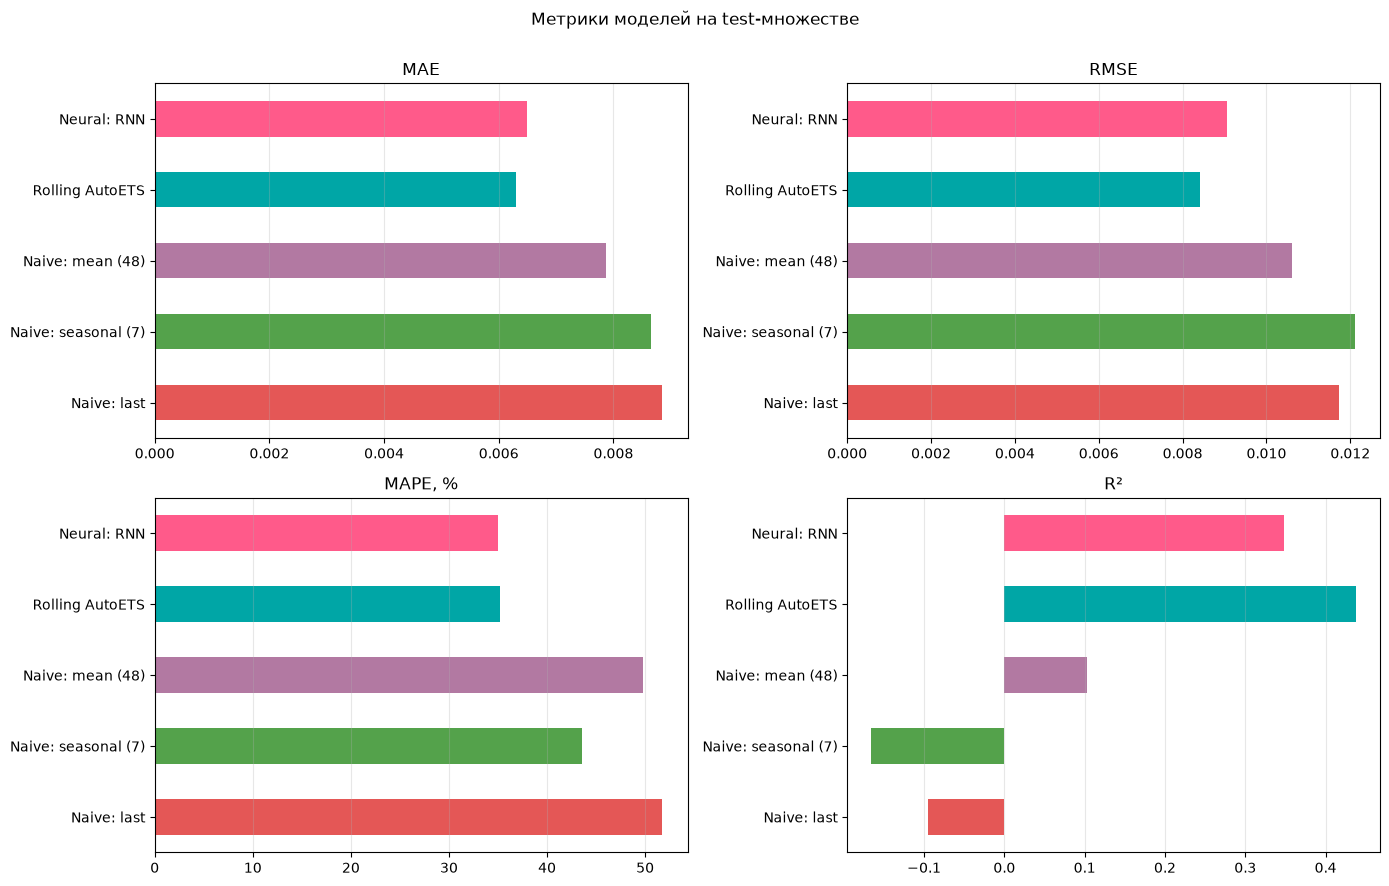

In [122]:
metrics = {}

for name, predictions in comparison_predictions.items():
    y_pred = predictions.reindex(naive_y_test.index)

    metrics[name] = {
        "MAE": mean_absolute_error(naive_y_test, y_pred),
        "RMSE": mean_squared_error(
            naive_y_test,
            y_pred,
        ) ** 0.5,
        "MAPE, %": mean_absolute_percentage_error(
            naive_y_test,
            y_pred,
        ) * 100,
        "R²": r2_score(naive_y_test, y_pred),
    }

metrics_table = pd.DataFrame(metrics).T
display(metrics_table.round(4))


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
)

for metric, ax in zip(
    metrics_table.columns,
    axes.flatten(),
):
    metrics_table[metric].plot.barh(
        ax=ax,
        color=[
            model_colors[name]
            for name in metrics_table.index
        ],
    )

    ax.set_title(metric)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle(
    "Метрики моделей на test-множестве\n"
)

plt.tight_layout()
plt.show()

## Сравниваем итоги